In [1]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
from shapely.validation import make_valid
from shapely.geometry import Polygon, MultiPolygon
from shapely.strtree import STRtree
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import warnings
from tqdm import tqdm
import time
import os
import glob

warnings.filterwarnings('ignore')

# ============================================================================
# ЭТАП 1: ЗАГРУЗКА ДАННЫХ
# ============================================================================
print("=" * 80)
print("ЭТАП 1: Загрузка данных")
print("=" * 80)

# Функция для поиска файла в поддиректориях
def find_file(filename, search_path='.'):
    for root, dirs, files in os.walk(search_path):
        if filename in files:
            return os.path.join(root, filename)
    return None

# Поиск файла
file_name = 'cup_it_example_src_A.csv'
file_path = find_file(file_name)

if file_path is None:
    print(f"Файл {file_name} не найден. Ищем все CSV файлы...")
    csv_files = glob.glob('**/*.csv', recursive=True)
    if csv_files:
        print(f"Найдены CSV файлы:")
        for f in csv_files[:5]:
            print(f"  {f}")
        file_path = csv_files[0]
        print(f"\nИспользуем файл: {file_path}")
    else:
        raise FileNotFoundError(f"Не удалось найти файл {file_name}")

# Загружаем CSV
df_original = pd.read_csv(file_path, encoding='utf-8', low_memory=False)
print(f"✓ Загружено записей: {len(df_original):,}")

# Создаем копию для обработки
df = df_original.copy()

# ============================================================================
# ЭТАП 2: ПРЕОБРАЗОВАНИЕ WKT В ГЕОМЕТРИЮ
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 2: Преобразование WKT в геометрию")
print("=" * 80)

def safe_wkt_to_geometry(wkt_str):
    """Безопасное преобразование WKT строки в геометрию Shapely."""
    if not isinstance(wkt_str, str) or not wkt_str.strip():
        return None
    try:
        geom = gpd.GeoSeries.from_wkt([wkt_str])[0]
        if geom is not None and not geom.is_empty:
            return geom
        return None
    except Exception:
        return None

# Применяем преобразование
print("  Преобразование геометрий...")
df['geometry_original'] = df['geometry'].copy()
df['geometry'] = df['geometry'].apply(safe_wkt_to_geometry)
initial_count = len(df)
df = df.dropna(subset=['geometry'])
print(f"✓ Удалено записей с некорректной геометрией: {initial_count - len(df):,}")
print(f"✓ Осталось записей: {len(df):,}")

# ============================================================================
# ЭТАП 3: СОЗДАНИЕ GEODATAFRAME И ПРОЕЦИРОВАНИЕ
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 3: Создание GeoDataFrame и проецирование")
print("=" * 80)

# Создаем GeoDataFrame с исходной системой координат WGS84 (EPSG:4326)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')
print(f"✓ Создан GeoDataFrame с {len(gdf):,} объектами")

# Перепроецируем в метрическую систему UTM зона 35N (для Санкт-Петербурга)
start_time = time.time()
gdf = gdf.to_crs('EPSG:32635')
print(f"✓ Перепроецировано в EPSG:32635 (UTM zone 35N) за {time.time() - start_time:.2f} сек")

# ============================================================================
# ЭТАП 4: РАСЧЕТ ПЛОЩАДЕЙ
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 4: Расчет площадей")
print("=" * 80)

# Вычисляем площади всех объектов в квадратных метрах
gdf['area_m2'] = gdf.geometry.area
print(f"✓ Площади рассчитаны")
print(f"  - Минимальная площадь: {gdf['area_m2'].min():.2f} м²")
print(f"  - Максимальная площадь: {gdf['area_m2'].max():.2f} м²")
print(f"  - Средняя площадь: {gdf['area_m2'].mean():.2f} м²")
print(f"  - Медианная площадь: {gdf['area_m2'].median():.2f} м²")
print(f"  - 99-й перцентиль: {gdf['area_m2'].quantile(0.99):.2f} м²")

# ============================================================================
# ЭТАП 5: ФИЛЬТРАЦИЯ ПО ПЛОЩАДИ (УДАЛЕНИЕ МАЛЕНЬКИХ ПОЛИГОНОВ)
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 5: Фильтрация по площади (удаление маленьких полигонов)")
print("=" * 80)

# Удаляем объекты с площадью менее 30 м² - это явные артефакты
min_area = 30.0
initial_count = len(gdf)
gdf = gdf[gdf['area_m2'] >= min_area]
print(f"✓ Удалено объектов с площадью < {min_area} м²: {initial_count - len(gdf):,}")
print(f"✓ Осталось объектов: {len(gdf):,}")

# ============================================================================
# ЭТАП 6: СТАТИСТИЧЕСКАЯ ФИЛЬТРАЦИЯ ВЫБРОСОВ ПО ПЛОЩАДИ (ВЕРХНЯЯ ГРАНИЦА)
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 6: Статистическая фильтрация выбросов по площади (верхняя граница)")
print("=" * 80)

# Альтернативные методы расчета верхней границы площади
print(f"Альтернативные методы расчета верхней границы площади:")

# Метод 1: Используем 99-й перцентиль + 20% запас
upper_area_bound_method1 = gdf['area_m2'].quantile(0.99) * 1.2
print(f"  - Метод 1 (99-й перцентиль * 1.2): {upper_area_bound_method1:.2f} м²")

# Метод 2: Используем медиану + 3*стандартное отклонение
std_area = gdf['area_m2'].std()
median_area = gdf['area_m2'].median()
upper_area_bound_method2 = median_area + 3 * std_area
print(f"  - Метод 2 (Медиана + 3*σ): {upper_area_bound_method2:.2f} м²")

# Метод 3: Используем IQR (Q3 + 3*IQR) - классический метод для выбросов
Q1_area = gdf['area_m2'].quantile(0.25)
Q3_area = gdf['area_m2'].quantile(0.75)
IQR_area = Q3_area - Q1_area
upper_area_bound_method3 = Q3_area + 3 * IQR_area
print(f"  - Метод 3 (Q3 + 3*IQR): {upper_area_bound_method3:.2f} м²")

# Выбираем метод 3 (IQR) как наиболее статистически обоснованный
# Но ограничиваем разумным максимумом для Санкт-Петербурга (5000 м²)
upper_area_bound = min(upper_area_bound_method3, 5000.0)

print(f"\nВыбранные границы фильтрации по площади:")
print(f"  - Нижняя граница (фиксированная): {min_area:.2f} м²")
print(f"  - Верхняя граница (IQR метод, ограничено 5000): {upper_area_bound:.2f} м²")

# Применяем фильтрацию
initial_count = len(gdf)
gdf = gdf[gdf['area_m2'] <= upper_area_bound]
print(f"\n✓ Удалено объектов с аномально большой площадью: {initial_count - len(gdf):,}")
print(f"✓ Осталось объектов: {len(gdf):,}")

# Дополнительная статистика после фильтрации
print(f"\nСтатистика площадей после фильтрации:")
print(f"  - Минимальная площадь: {gdf['area_m2'].min():.2f} м²")
print(f"  - Максимальная площадь: {gdf['area_m2'].max():.2f} м²")
print(f"  - Средняя площадь: {gdf['area_m2'].mean():.2f} м²")
print(f"  - Медианная площадь: {gdf['area_m2'].median():.2f} м²")

# ============================================================================
# ЭТАП 7: РЕМОНТ НЕВАЛИДНОЙ ГЕОМЕТРИИ
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 7: Ремонт невалидной геометрии")
print("=" * 80)

# Проверяем геометрии на валидность
invalid_mask = ~gdf.geometry.is_valid
invalid_count = invalid_mask.sum()
if invalid_count > 0:
    print(f"✓ Найдено невалидных геометрий: {invalid_count:,} ({invalid_count/len(gdf)*100:.2f}%)")

    def repair_geometry(geom):
        """Ремонт невалидной геометрии"""
        if geom is None or geom.is_empty:
            return None
        if geom.is_valid:
            return geom
        try:
            repaired = make_valid(geom)
            if repaired.geom_type == 'GeometryCollection':
                polygons = [g for g in repaired.geoms if g.geom_type in ['Polygon', 'MultiPolygon']]
                if not polygons:
                    return None
                repaired = polygons[0] if len(polygons) == 1 else MultiPolygon(polygons)
            if repaired.area < 1e-6:
                return None
            return repaired
        except Exception:
            return None

    print("  Ремонт геометрий...")
    repaired_geoms = []
    for idx, row in tqdm(gdf[invalid_mask].iterrows(), total=invalid_count, desc="  Прогресс"):
        repaired = repair_geometry(row.geometry)
        repaired_geoms.append(repaired)

    # Обновляем геометрии
    gdf.loc[invalid_mask, 'geometry'] = repaired_geoms
    # Удаляем объекты, которые не удалось исправить
    gdf = gdf.dropna(subset=['geometry'])
    gdf = gdf[~gdf.geometry.is_empty]
    print(f"✓ Осталось объектов после ремонта: {len(gdf):,}")

    # Пересчитываем площади после ремонта
    gdf['area_m2'] = gdf.geometry.area
else:
    print("✓ Все геометрии валидны")

# ============================================================================
# ЭТАП 8: ОПТИМИЗАЦИЯ ДАННЫХ
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 8: Оптимизация данных")
print("=" * 80)

# Упрощаем геометрию с допустимым отклонением 0.1 метра
print("  Упрощение геометрии...")
start_time = time.time()
gdf['geometry'] = gdf.geometry.simplify(0.1, preserve_topology=True)
print(f"  ✓ Упрощение завершено за {time.time() - start_time:.2f} сек")


ЭТАП 1: Загрузка данных
✓ Загружено записей: 171,454

ЭТАП 2: Преобразование WKT в геометрию
  Преобразование геометрий...
✓ Удалено записей с некорректной геометрией: 0
✓ Осталось записей: 171,454

ЭТАП 3: Создание GeoDataFrame и проецирование
✓ Создан GeoDataFrame с 171,454 объектами
✓ Перепроецировано в EPSG:32635 (UTM zone 35N) за 0.27 сек

ЭТАП 4: Расчет площадей
✓ Площади рассчитаны
  - Минимальная площадь: 0.31 м²
  - Максимальная площадь: 137722.73 м²
  - Средняя площадь: 504.39 м²
  - Медианная площадь: 118.88 м²
  - 99-й перцентиль: 4826.61 м²

ЭТАП 5: Фильтрация по площади (удаление маленьких полигонов)
✓ Удалено объектов с площадью < 30.0 м²: 31,587
✓ Осталось объектов: 139,867

ЭТАП 6: Статистическая фильтрация выбросов по площади (верхняя граница)
Альтернативные методы расчета верхней границы площади:
  - Метод 1 (99-й перцентиль * 1.2): 6510.23 м²
  - Метод 2 (Медиана + 3*σ): 5005.50 м²
  - Метод 3 (Q3 + 3*IQR): 2468.34 м²

Выбранные границы фильтрации по площади:
  - Ни

In [2]:
gdf.head()

,Unnamed: 0,id,title,tags,geometry,area_sq_m,gkh_address,gkh_floor_count_min,gkh_floor_count_max,geometry_original,area_m2
0,0,1,NaN,"['постройка, сооружение']","MULTIPOLYGON (((673857.826 6635491.726, 673852...",84.94625,NaN,NaN,NaN,"MULTIPOLYGON (((30.10095 59.82052, 30.10085 59...",84.998796
1,1,2,NaN,"['постройка, сооружение']","MULTIPOLYGON (((673877.139 6635487.054, 673874...",114.67415,NaN,NaN,NaN,"MULTIPOLYGON (((30.10129 59.82047, 30.10124 59...",114.686068
2,2,3,NaN,['жилое здание'],"MULTIPOLYGON (((677085.217 6640425.771, 677085...",122.99800,NaN,NaN,NaN,"MULTIPOLYGON (((30.16261 59.86339, 30.1626 59....",122.970600
3,3,4,NaN,['культура и отдых'],"MULTIPOLYGON (((677492.717 6654087.455, 677496...",64.16945,NaN,NaN,NaN,"MULTIPOLYGON (((30.18159 59.9857, 30.18167 59....",64.058721
4,4,5,NaN,['культура и отдых'],"MULTIPOLYGON (((677493.693 6654102.002, 677491...",170.71815,NaN,NaN,NaN,"MULTIPOLYGON (((30.18162 59.98583, 30.1816 59....",170.719519


In [3]:
gdf = gdf.reset_index(drop=True)

  Создание пространственного индекса...
  ✓ Пространственный индекс создан за 0.14 сек

ЭТАП 9: Построение графа касаний
  Добавление 134,360 вершин...
✓ Добавлено 134,360 вершин

  Поиск касающихся и близкорасположенных полигонов...
  Параметры поиска: max_overlap_ratio=10%, min_touch_distance=0.5 м


  Обработка полигонов: 134460it [00:14, 9066.25it/s]                             


✓ Граф построен. Количество ребер: 55,811

ЭТАП 10: Анализ графа

Основные характеристики:
  - Количество вершин: 134,360
  - Количество ребер: 55,811

  Компоненты связности:
  - Количество компонент: 88,052
  - Размер компонент:
    * Минимальный: 1
    * Максимальный: 92
    * Медианный: 1
    * Средний: 1.53

  Степени вершин:
  - Минимальная степень: 0
  - Максимальная степень: 20
  - Средняя степень: 0.83
  - Медианная степень: 0

  Распределение степеней (топ-10):
    * Степень 0: 73,905 вершин (55.01%)
    * Степень 1: 32,398 вершин (24.11%)
    * Степень 2: 15,272 вершин (11.37%)
    * Степень 3: 7,112 вершин (5.29%)
    * Степень 4: 3,196 вершин (2.38%)
    * Степень 5: 1,394 вершин (1.04%)
    * Степень 6: 560 вершин (0.42%)
    * Степень 7: 258 вершин (0.19%)
    * Степень 8: 125 вершин (0.09%)
    * Степень 9: 69 вершин (0.05%)
    * Степень 10: 37 вершин (0.03%)

ЭТАП 11: Визуализация результатов

  Визуализация крупнейшей компоненты (92 вершин)...


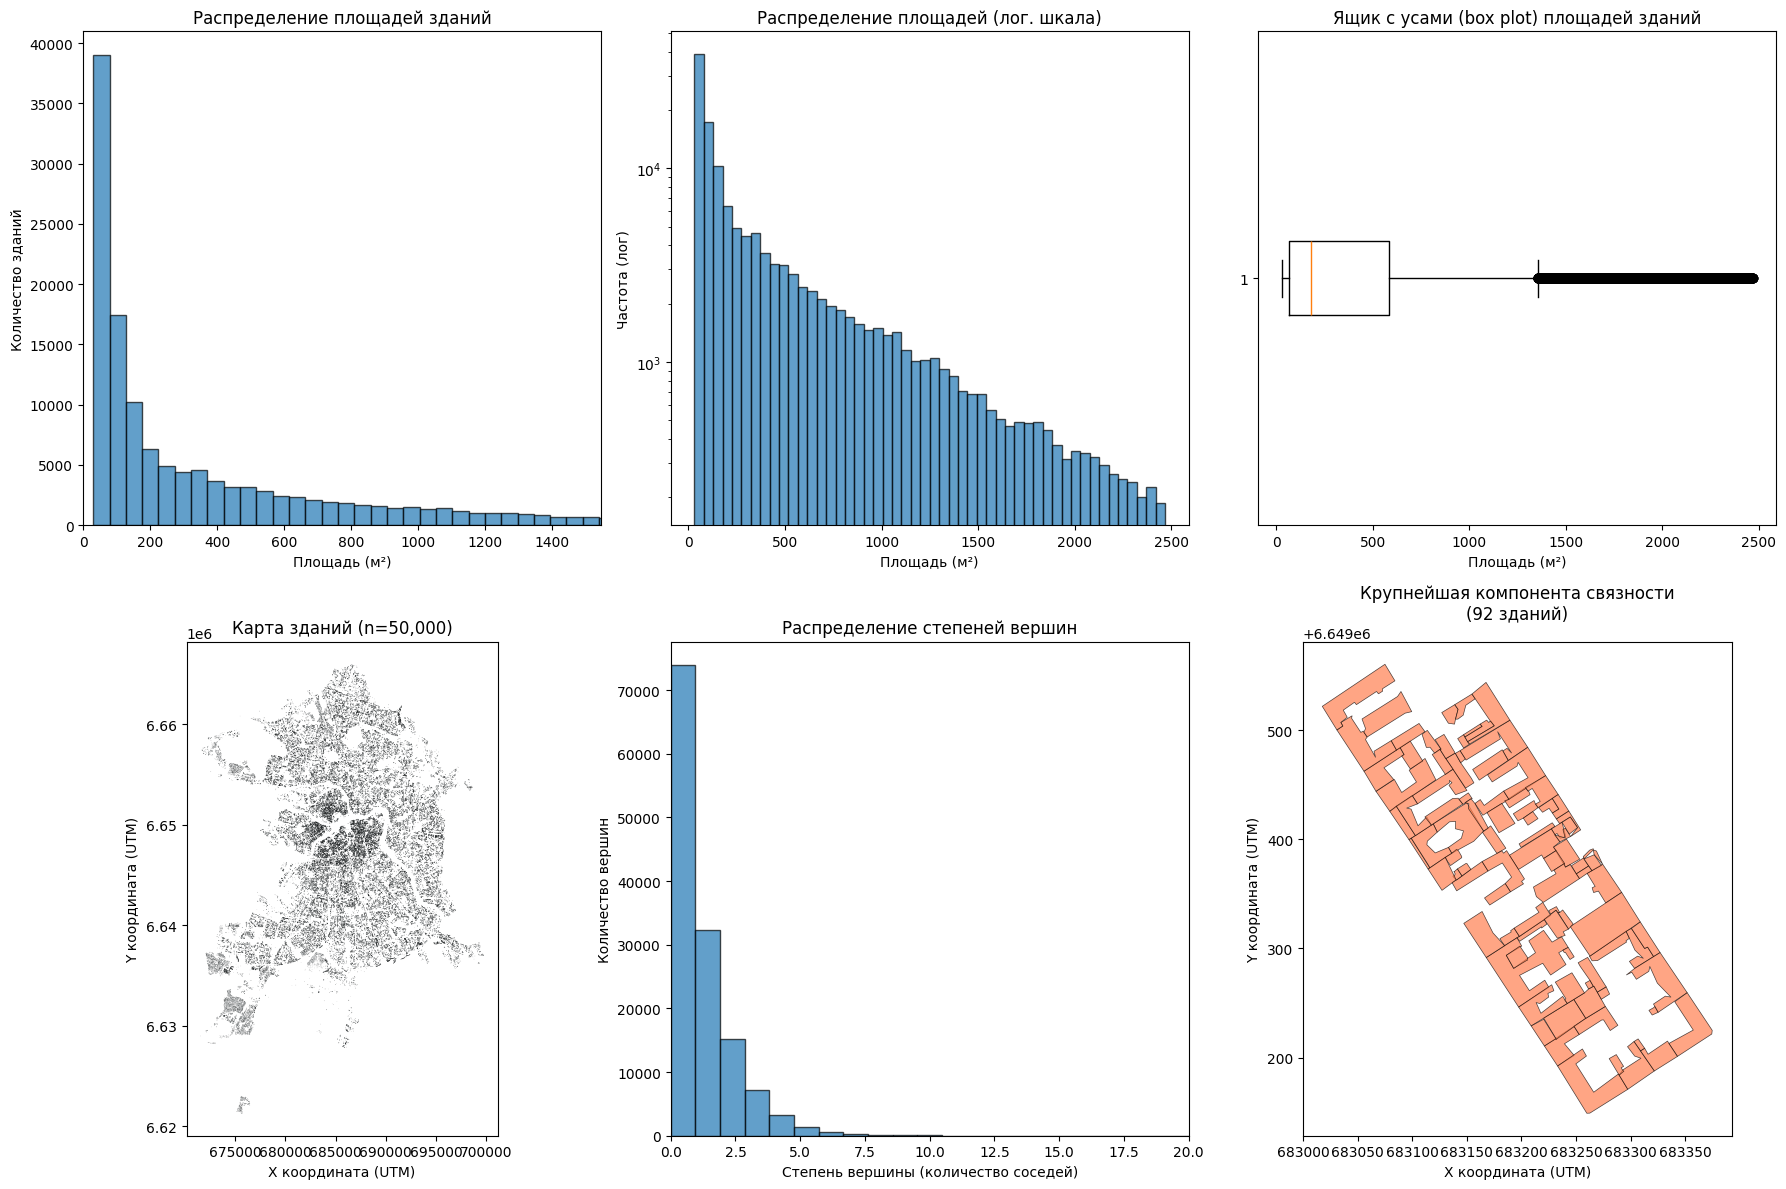


ИТОГОВАЯ СТАТИСТИКА ОБРАБОТКИ

Начальное количество записей: 171,454
Количество объектов после всех этапов очистки: 134,360
Удалено объектов: 37,094 (21.63%)

Количество вершин в графе: 134,360
Количество ребер в графе: 55,811

Компоненты связности:
  - Количество компонент: 88,052
  - Размер крупнейшей компоненты: 92
  - Количество изолированных зданий: 73,905

Статистика площадей после очистки:
  - Минимальная: 30.00 м²
  - Максимальная: 2467.82 м²
  - Средняя: 416.79 м²
  - Медианная: 179.74 м²

✓ Очищенные данные сохранены в: cleaned_buildings_A.geojson

ОБРАБОТКА ЗАВЕРШЕНА


In [4]:
# Создаем пространственный индекс STRtree для быстрого поиска соседей
print("  Создание пространственного индекса...")
start_time = time.time()
geometries_list = list(gdf.geometry.values)
spatial_index = STRtree(geometries_list)
idx_to_original = {i: orig_idx for i, orig_idx in enumerate(gdf.index)}
print(f"  ✓ Пространственный индекс создан за {time.time() - start_time:.2f} сек")

# ============================================================================
# ЭТАП 9: ПОСТРОЕНИЕ ГРАФА КАСАНИЙ
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 9: Построение графа касаний")
print("=" * 80)

# Создаем пустой граф
G = nx.Graph()
print(f"  Добавление {len(gdf):,} вершин...")
for idx in gdf.index:
    G.add_node(idx)
print(f"✓ Добавлено {G.number_of_nodes():,} вершин")

def check_intersecting(geom1, geom2):
    return geom1.intersects(geom2)

def check_touching(geom1, geom2, max_overlap_ratio=0.1, min_touch_distance=0.5):
    """
    Проверка касания между полигонами.

    Параметры:
    - max_overlap_ratio: максимальное допустимое отношение площади пересечения
                         к площади меньшего полигона (10% по умолчанию)
    - min_touch_distance: минимальное расстояние между полигонами,
                          при котором они считаются касающимися (0.5 м по умолчанию)
    """
    if geom1.intersects(geom2):
        intersection = geom1.intersection(geom2)
        if intersection.area > 0:
            min_area_poly = min(geom1.area, geom2.area)
            overlap_ratio = intersection.area / min_area_poly
            if overlap_ratio <= max_overlap_ratio:
                return True
        elif intersection.area == 0:
            return True

    distance = geom1.distance(geom2)
    if distance <= min_touch_distance and distance > 0:
        return True

    return False

print("\n  Поиск касающихся и близкорасположенных полигонов...")
print(f"  Параметры поиска: max_overlap_ratio=10%, min_touch_distance=0.5 м")
edges_list = []
edges_found = 0

# Используем прогресс-бар для отслеживания выполнения
with tqdm(total=len(gdf), desc="  Обработка полигонов") as pbar:
    for i, (idx, row) in enumerate(gdf.iterrows()):
        geom_i = row.geometry
        # Увеличиваем буфер поиска до 2 метров для ускорения
        buffer_geom = geom_i.buffer(2.0)
        # Находим кандидатов с помощью пространственного индекса
        candidate_indices = spatial_index.query(buffer_geom)

        for j in candidate_indices:
            j_idx = idx_to_original[j]
            # Проверяем только пары с i < j, чтобы избежать дублирования
            if idx >= j_idx:
                continue
            geom_j = gdf.loc[j_idx].geometry

            # Проверяем связь (касание или близкое расположение)
            if check_intersecting(geom_i, geom_j):
                edges_list.append((idx, j_idx))
                edges_found += 1

        # Обновляем прогресс-бар каждые 100 объектов
        if i % 100 == 0:
            pbar.update(100)
    pbar.update(len(gdf) % 100)

# Добавляем все найденные ребра в граф
G.add_edges_from(edges_list)
print(f"✓ Граф построен. Количество ребер: {edges_found:,}")

# ============================================================================
# ЭТАП 10: АНАЛИЗ ГРАФА
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 10: Анализ графа")
print("=" * 80)

if G.number_of_nodes() > 0:
    print(f"\nОсновные характеристики:")
    print(f"  - Количество вершин: {G.number_of_nodes():,}")
    print(f"  - Количество ребер: {G.number_of_edges():,}")

    # Находим компоненты связности
    components = list(nx.connected_components(G))
    component_sizes = [len(c) for c in components]

    print(f"\n  Компоненты связности:")
    print(f"  - Количество компонент: {len(components):,}")
    print(f"  - Размер компонент:")
    print(f"    * Минимальный: {min(component_sizes):,}")
    print(f"    * Максимальный: {max(component_sizes):,}")
    print(f"    * Медианный: {np.median(component_sizes):.0f}")
    print(f"    * Средний: {np.mean(component_sizes):.2f}")

    # Степени вершин
    degrees = [d for n, d in G.degree()]
    print(f"\n  Степени вершин:")
    print(f"  - Минимальная степень: {min(degrees)}")
    print(f"  - Максимальная степень: {max(degrees)}")
    print(f"  - Средняя степень: {np.mean(degrees):.2f}")
    print(f"  - Медианная степень: {np.median(degrees):.0f}")

    # Распределение степеней
    degree_counts = np.bincount(degrees)
    print(f"\n  Распределение степеней (топ-10):")
    for deg, count in enumerate(degree_counts):
        if count > 0 and deg <= 10:
            print(f"    * Степень {deg}: {count:,} вершин ({count/len(degrees)*100:.2f}%)")

# ============================================================================
# ЭТАП 11: ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 11: Визуализация результатов")
print("=" * 80)

# Создаем фигуру с 2x3 подграфиками
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Гистограмма площадей
axes[0, 0].hist(gdf['area_m2'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Распределение площадей зданий', fontsize=12)
axes[0, 0].set_xlabel('Площадь (м²)')
axes[0, 0].set_ylabel('Количество зданий')
axes[0, 0].set_xlim(0, gdf['area_m2'].quantile(0.95))

# 2. Логарифмическая гистограмма площадей
axes[0, 1].hist(gdf['area_m2'], bins=50, edgecolor='black', alpha=0.7, log=True)
axes[0, 1].set_title('Распределение площадей (лог. шкала)', fontsize=12)
axes[0, 1].set_xlabel('Площадь (м²)')
axes[0, 1].set_ylabel('Частота (лог)')

# 3. Ящик с усами (box plot) для площадей
axes[0, 2].boxplot(gdf['area_m2'], vert=False)
axes[0, 2].set_title('Ящик с усами (box plot) площадей зданий', fontsize=12)
axes[0, 2].set_xlabel('Площадь (м²)')

# 4. Карта всех зданий
sample_size = min(50000, len(gdf))
if sample_size > 0:
    gdf_sample = gdf.sample(n=sample_size, random_state=42) if len(gdf) > sample_size else gdf
    gdf_sample.plot(ax=axes[1, 0], edgecolor='black', facecolor='lightblue', alpha=0.5, linewidth=0.3, markersize=0.5)
    axes[1, 0].set_title(f'Карта зданий (n={sample_size:,})', fontsize=12)
    axes[1, 0].set_xlabel('X координата (UTM)')
    axes[1, 0].set_ylabel('Y координата (UTM)')

# 5. Распределение степеней вершин
if G.number_of_nodes() > 0:
    axes[1, 1].hist(degrees, bins=min(30, max(degrees)+1), edgecolor='black', alpha=0.7)
    axes[1, 1].set_title('Распределение степеней вершин', fontsize=12)
    axes[1, 1].set_xlabel('Степень вершины (количество соседей)')
    axes[1, 1].set_ylabel('Количество вершин')
    axes[1, 1].set_xlim(0, min(20, max(degrees)))

# 6. Визуализация крупнейшей компоненты связности
if len(components) > 0:
    largest_component = max(components, key=len)
    print(f"\n  Визуализация крупнейшей компоненты ({len(largest_component):,} вершин)...")

    if len(largest_component) <= 20000:
        largest_gdf = gdf.loc[list(largest_component)]
        largest_gdf.plot(ax=axes[1, 2], edgecolor='black', facecolor='coral', alpha=0.7, linewidth=0.5)
        axes[1, 2].set_title(f'Крупнейшая компонента связности\n({len(largest_component):,} зданий)', fontsize=12)
        axes[1, 2].set_xlabel('X координата (UTM)')
        axes[1, 2].set_ylabel('Y координата (UTM)')
    else:
        axes[1, 2].text(0.5, 0.5, f'Компонента слишком большая\n({len(largest_component):,} вершин)\nдля визуализации',
                       horizontalalignment='center', verticalalignment='center', transform=axes[1, 2].transAxes, fontsize=12)
        axes[1, 2].set_title('Крупнейшая компонента связности', fontsize=12)

plt.tight_layout()
plt.show()

# ============================================================================
# ИТОГОВАЯ СТАТИСТИКА
# ============================================================================
print("\n" + "=" * 80)
print("ИТОГОВАЯ СТАТИСТИКА ОБРАБОТКИ")
print("=" * 80)

# Используем df_original, который сохранили в начале
print(f"\nНачальное количество записей: {len(df_original):,}")
print(f"Количество объектов после всех этапов очистки: {len(gdf):,}")
print(f"Удалено объектов: {len(df_original) - len(gdf):,} ({100*(1 - len(gdf)/len(df_original)):.2f}%)")
print(f"\nКоличество вершин в графе: {G.number_of_nodes():,}")
print(f"Количество ребер в графе: {G.number_of_edges():,}")

if len(components) > 0:
    print(f"\nКомпоненты связности:")
    print(f"  - Количество компонент: {len(components):,}")
    print(f"  - Размер крупнейшей компоненты: {max(component_sizes):,}")
    isolated_count = sum(1 for s in component_sizes if s == 1)
    print(f"  - Количество изолированных зданий: {isolated_count:,}")

print(f"\nСтатистика площадей после очистки:")
print(f"  - Минимальная: {gdf['area_m2'].min():.2f} м²")
print(f"  - Максимальная: {gdf['area_m2'].max():.2f} м²")
print(f"  - Средняя: {gdf['area_m2'].mean():.2f} м²")
print(f"  - Медианная: {gdf['area_m2'].median():.2f} м²")

# Сохраняем результат
output_file = 'cleaned_buildings_A.geojson'
gdf.to_file(output_file, driver='GeoJSON')
print(f"\n✓ Очищенные данные сохранены в: {output_file}")

print("\n" + "=" * 80)
print("ОБРАБОТКА ЗАВЕРШЕНА")
print("=" * 80)

In [5]:
from shapely import Point

# Объединение фигур
def union(geometries):
    if len(geometries) == 0:
        return Point()
    
    base = geometries[0]

    for i in range(1, len(geometries)):
        base = base.union(geometries[i])

    return base

comp_geom = [gdf.geometry.values[list(c)] for c in components]
comp_unions = [union(comp) for comp in comp_geom]
single_components = [list(c)[0] for c in components if len(c) == 1]
comp_centers = [u.centroid for u in comp_unions]

In [6]:
component_idx = [0] * len(gdf)
is_isolated = [False] * len(gdf)
centroids = [None] * len(gdf)
unions = [None] * len(gdf)

for i, c in enumerate(components):
    for ci in list(c):
        component_idx[ci] = i
        is_isolated[ci] = len(c) == 1
        centroids[ci] = comp_centers[i]
        unions[ci] = comp_unions[i]

gdf['component'] = component_idx
gdf['is_isolated'] = is_isolated
gdf['centroid'] = centroids
gdf['union'] = unions

In [7]:
gdf.columns

Index(['Unnamed: 0', 'id', 'title', 'tags', 'geometry', 'area_sq_m',
       'gkh_address', 'gkh_floor_count_min', 'gkh_floor_count_max',
       'geometry_original', 'area_m2', 'component', 'is_isolated', 'centroid',
       'union'],
      dtype='str')

In [8]:
gdf.drop(columns=['Unnamed: 0', 'id'], inplace=True)

In [9]:
gdf.to_csv('cup_it_example_src_A_cleaned.csv')

In [31]:
gdf['union'].head()

0    MULTIPOLYGON (((337456.9496764267 6634979.1187...
1    MULTIPOLYGON (((337475.7610651871 6634972.7199...
2    POLYGON ((341087.21240128635 6639622.121584475...
3    POLYGON ((342771.3963149669 6653181.916941152,...
4    POLYGON ((342771.3963149669 6653181.916941152,...
Name: union, dtype: object